# Neighborhood analysis with just immune cells - normalizing by area and based on comparisons of interest

Manish wants to focus on just immune cells to see what going on with them. Here we will normalize the proportions based on the whole area of each ROI. 

In [106]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time
import sys
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import seaborn as sns
import math
import os
import re

from scipy.spatial import cKDTree
from scipy.spatial import distance_matrix
from scipy.stats import ttest_ind
from itertools import combinations
import pandas as pd
import statsmodels.stats.multitest as smm

import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

The ROIs I am working with:

In [107]:
path = "/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/"

all_files = os.listdir(path)
pattern = re.compile(r'(.+)_sigma_binary_res')

# Extract matching sample names
sample_names = []
for file in all_files:
    match = pattern.match(file)
    if match:
        sample_names.append(match.group(1)) 

In [108]:
sample_names

['23257_A7_T3_tumor_bed',
 'S24-35674_A9_peritumoral_area',
 'BMS23-6679_C_tumor',
 'S23-38315_A3_tumor_inner',
 'BMS23-11362_C8_tumor_inner',
 'BMSS23-8749_28835_tumor',
 'S24-30054_A11_T3_entire_image',
 'S24-12214_C1_tumor',
 'BMS23-9784_A6_31737_tumor_bed',
 'S24-22889_A6_tumor_inner',
 'S24-22889_A6_peritumoral_area',
 'S23-47115_A6_tumor_bed',
 'S24-11672_G1_tumor',
 'S23-18584_A5_tumor_bed',
 'S24-35674_A9_tumor_inner',
 'S24-21915_A5_tumor_bed',
 'S23-21917_A6_tumor_bed',
 'BMS23-7393_C_tumor',
 'BMS24-11260_D_tumor',
 'S23-38315_A3_peritumoral_area',
 'BMS23-39313_C_tumor']

In [109]:
#create def to create a new table:
all_sample_merged_table= []
for sample_name in sample_names:
    annota_table = pd.read_table(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/cell_annotation.txt')
    raw_table = pd.read_csv(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/raw_metadata.csv')
    #print(annota_table['cell_id'].isin(raw_table['Object Id']).all())
    merged_table = pd.merge(
        raw_table,
        annota_table,
        left_on='Object Id',
        right_on='cell_id',
        how='inner'
    )
    merged_table['sample_region']=sample_name
    all_sample_merged_table.append(merged_table)

all_sample_merged_table = pd.concat(all_sample_merged_table, axis=0).reset_index(drop=True)

In [110]:
all_zscore_table= []
for sample_name in sample_names:
    norm_data = pd.read_csv(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/z_score_normalization.csv')
    norm_data['sample_region']=sample_name
    all_zscore_table.append(norm_data)

all_zscore_table = pd.concat(all_zscore_table, axis=0).reset_index(drop=True)

In [111]:
all_sample_merged_table2 = all_sample_merged_table

In [112]:
all_sample_merged_table2.loc[all_sample_merged_table2['sample_region'] == 'BMS23-11362_C8_tumor_inner', 'sample_region'] = 'BMS23-11362_C8_tumor_bed'

In [113]:
normalized_df = all_sample_merged_table2.merge(all_zscore_table, on=['cell_id', 'sample_region'], how='left')


In [114]:
#select just the sample names, cell type of interest, X_mean and Y_mean and Cell Area
columns_to_Select = ['sample_region','celll_type','Cell Area (µm²)','xmean', 'ymean']
sub_df = normalized_df[columns_to_Select]

In [115]:
regions = ["tumor_inner", "tumor_bed", "peritumoral_area", "tumor"]

# Create regex pattern
pattern = re.compile(rf"({'|'.join(regions)})$")

# Split into sample_id and region
data = []
for s in sub_df['sample_region']:
    match = pattern.search(s)
    if match:
        region = match.group(1)
        sample_id = s.replace("_" + region, "")
    else:
        region = "other"
        sample_id = s
    data.append((sample_id, region))

df = pd.DataFrame(data, columns=["Sample_name", "ROI"])

In [116]:
sub_df['Sample_name']=df['Sample_name'].values
sub_df['ROI']=df['ROI'].values

/tmp/ipykernel_4007144/3721613111.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['Sample_name']=df['Sample_name'].values
/tmp/ipykernel_4007144/3721613111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['ROI']=df['ROI'].values


In [117]:
sample_map = pd.read_csv("/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/sample_conditions.csv")  
sample_map

,Sample_name,ROI,Condition,MSI,Internal
0,23257_A7_T3,tumor_bed,Responder,No,Resection
1,BMS23-11362_C8,tumor_bed,Responder,High,NaN
2,BMS23-39313_C,tumor,Responder,No,Baseline
3,BMS23-6679_C,tumor,Baseline,No,Baseline
4,BMS23-7393_C,tumor,Baseline,High,Baseline
5,BMS23-9784_A6_31737,tumor_bed,Responder,High,Resection
6,BMS24-11260_D,tumor,Baseline,No,Baseline
7,BMSS23-8749_28835,tumor,Non-responder,No,Resection
8,S23-18584_A5,tumor_bed,Responder,No,NaN
9,S23-21917_A6,tumor_bed,Responder,No,NaN


In [118]:
sub_df = pd.merge(
    sub_df, sample_map,
    left_on=["Sample_name", "ROI"],
    right_on=["Sample_name", "ROI"],
    how="inner"
)

Get the counts of all the differnet cell types and normalize them divind them by the whole area of the differnet ROIS.

In [119]:
counts_table = pd.crosstab(sub_df['sample_region'],sub_df['celll_type'])

In [120]:
area_sum = sub_df.groupby("sample_region")["Cell Area (µm²)"].sum()

In [121]:
normalized_area_table = counts_table.div(area_sum, axis=0)* 1000

In [122]:
unique_pairs = sub_df[['sample_region', 'Condition', "MSI", "Internal"]].drop_duplicates()
normalized_area_table_reset = normalized_area_table.reset_index()

merged_table = normalized_area_table_reset.merge(
    unique_pairs,
    on="sample_region",
    how="left"
)


In [123]:
immune_cells = ['B_cell','FOXP3','T_cell','CD8','CD8_LAG3_Tcell','CD4','CD4_Tcell', 'LAG3_Tcell', 'CD8_Tcell', 'T_regs', 'CD4_Tregs','CD4_LAG3_Tcell', 'CD8_Tregs', 'sample_region', 'Condition', 'MSI','Internal']
immune_normalized_area_table = merged_table[immune_cells]

# Proportion differences

## First comparison Responders vs Non-responders
Just internal tumor and no Peritumoral area

In [124]:
conditions_interest = ["Responder","Non-responder"]
ROI_interest = ["tumor_bed","tumor_inner"]

In [125]:
sub_interest1 = sub_df[sub_df['Condition'].isin(conditions_interest)]
sub_interest1 = sub_interest1[sub_interest1['ROI'].isin(ROI_interest)]
subset_table = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sub_interest1['sample_region'].unique())]

In [126]:
interest_sample_sub = immune_normalized_area_table[immune_normalized_area_table['sample_region'] == "BMSS23-8749_28835_tumor"]
subset_table = pd.concat([subset_table, interest_sample_sub], axis=0)
table_to_prov1 = subset_table.set_index(["Condition", "sample_region"])
table_to_prov1 = table_to_prov1.sort_index(level=["Condition", "sample_region"])
table_to_prov1.drop(['MSI','Internal'], axis=1, inplace=True)

In [127]:
def t_test_plot(prop_table, columns_interest):
    dataframe_interest = prop_table
    dataframe_interest.index.names = [columns_interest, 'sample_region']
    num_cell_types = dataframe_interest.shape[1]
    cmap = cm.get_cmap('tab20', num_cell_types)
    colors = [cmap(i) for i in range(num_cell_types)]

    ax = dataframe_interest.plot(kind='barh', stacked=True, figsize=(10, 6), color=colors)
    
    # add separator lines between conditions
    # get index levels
    conditions = dataframe_interest.index.get_level_values(0)
    for i in range(1, len(conditions)):
        if conditions[i] != conditions[i-1]:
            ax.axhline(i-0.5, color="black", linewidth=1)  # separator
    
    # legend outside
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(False)
    
    plt.title('Proportion of Cell Types per Sample')
    plt.xlabel('Proportion of Cells')
    plt.ylabel('Sample (grouped by Condition)')
    plt.tight_layout()
    plt.show()



    dataframe_interest[columns_interest] = dataframe_interest.index.get_level_values(columns_interest)
    results = []

    conditions = dataframe_interest[columns_interest].unique()
    
    for cell_type in dataframe_interest.columns:
        if cell_type != columns_interest:  # skip metadata
            # Loop over all pairwise comparisons
            for cond1, cond2 in combinations(conditions, 2):
                group1 = dataframe_interest.loc[dataframe_interest[columns_interest] == cond1, cell_type]
                group2 = dataframe_interest.loc[dataframe_interest[columns_interest] == cond2, cell_type]
    
                mean1 = group1.mean()
                mean2 = group2.mean()
    
                t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
    
                direction = f"up_in_{cond1}" if mean1 > mean2 else f"up_in_{cond2}"
    
                results.append({
                    "cell_type": cell_type,
                    "comparison": f"{cond1}_vs_{cond2}",
                    f"{cond1}_mean": mean1,
                    f"{cond2}_mean": mean2,
                    "t_stat": t_stat,
                    "p_val": p_val,
                    "direction": direction
                })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Correct for multiple testing (FDR)
    results_df["p_adj"] = smm.multipletests(results_df["p_val"], method="fdr_bh")[1]
    
    return ax, results_df

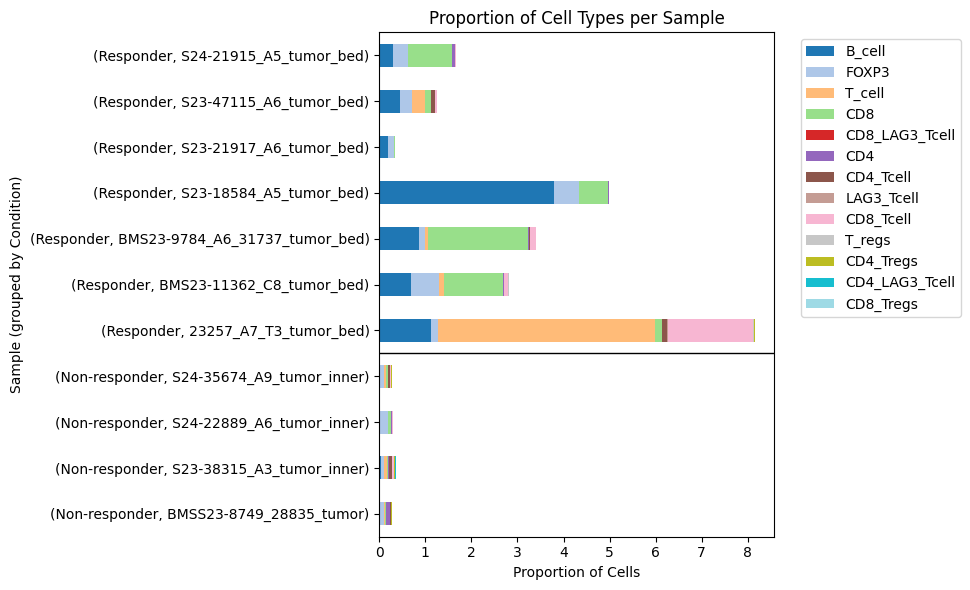

In [128]:
ax, results_df = t_test_plot(table_to_prov1, "Condition")

In [129]:
table_to_prov1.drop('Condition', axis=1, inplace=True)

In [130]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,Non-responder_mean,Responder_mean,t_stat,p_val,direction,p_adj
1,FOXP3,Non-responder_vs_Responder,0.103199,0.306229,-2.515594,0.040038,up_in_Responder,0.301817


In [131]:
def dot_plot_for_doron(prop_table, columns_interest, sample_order=None, palette=None):
    """
    prop_table: DataFrame with MultiIndex (Condition, sample_region) and cell types as columns
    sample_order: optional list of 'Condition_sample_region' labels to order on x-axis
    palette: optional dict mapping cell_type to colors
    """
    
    # Reset index to turn MultiIndex into columns
    df_long = prop_table.reset_index()
    
    # Melt the table: cell types become 'cell_type', values become 'proportion'
    df_long = df_long.melt(
        id_vars=[columns_interest, 'sample_region'],
        var_name='cell_type',
        value_name='proportion'
    )
    
    # Create combined label for x-axis
    df_long['cells_genotype'] = df_long[columns_interest].astype(str) + "_" + df_long['sample_region'].astype(str)
    
    # Apply custom order if provided
    if sample_order is not None:
        df_long['cells_genotype'] = pd.Categorical(df_long['cells_genotype'], categories=sample_order, ordered=True)
    
    # Use custom palette or fallback to tab20
    if palette is None:
        num_cell_types = df_long['cell_type'].nunique()
        cmap = cm.get_cmap('tab20', num_cell_types)
        palette = {ct: cmap(i) for i, ct in enumerate(df_long['cell_type'].unique())}
    
    # Plot dot plot
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_long,
        x='cells_genotype',
        y='cell_type',
        size='proportion',
        hue='cell_type',
        sizes=(20, 300),
        palette=palette
    )
    
    plt.title('Proportion of Cell Types per Sample')
    plt.xlabel('Sample Name')
    plt.ylabel('Cell Type')
    plt.xticks(rotation=90)
    plt.grid(False)
    sns.despine()
    
    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



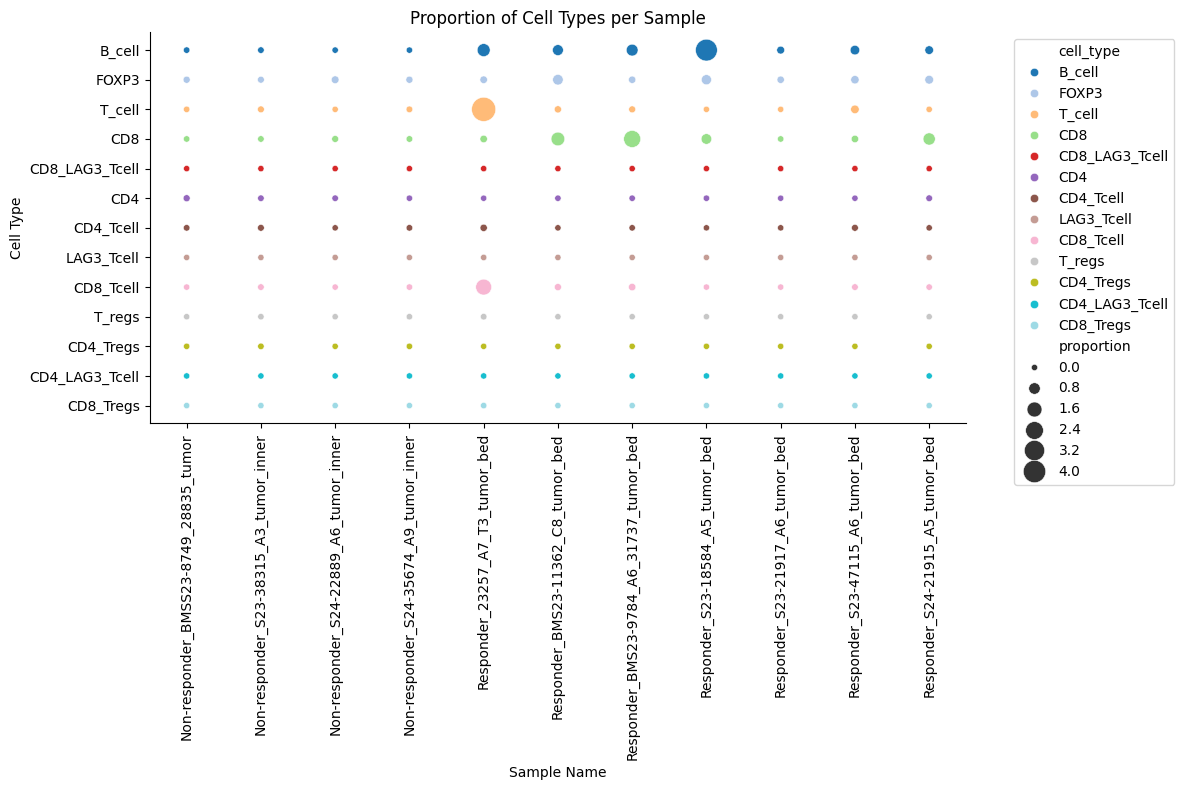

In [132]:
dot_plot_for_doron(table_to_prov1, "Condition")

## Second comparison: Responders MSI high vs MSI low

In [133]:
sub_interest1 = sub_df[sub_df['Condition']=="Responder"]
sub_interest1 = sub_interest1[sub_interest1['ROI']!="tumor"]

In [134]:
subset_table = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sub_interest1['sample_region'].unique())]

In [135]:
table_to_prov1 = subset_table.set_index(["MSI", "sample_region"])
table_to_prov1 = table_to_prov1.sort_index(level=["MSI", "sample_region"])
table_to_prov1.drop(['Condition','Internal'], axis=1, inplace=True)

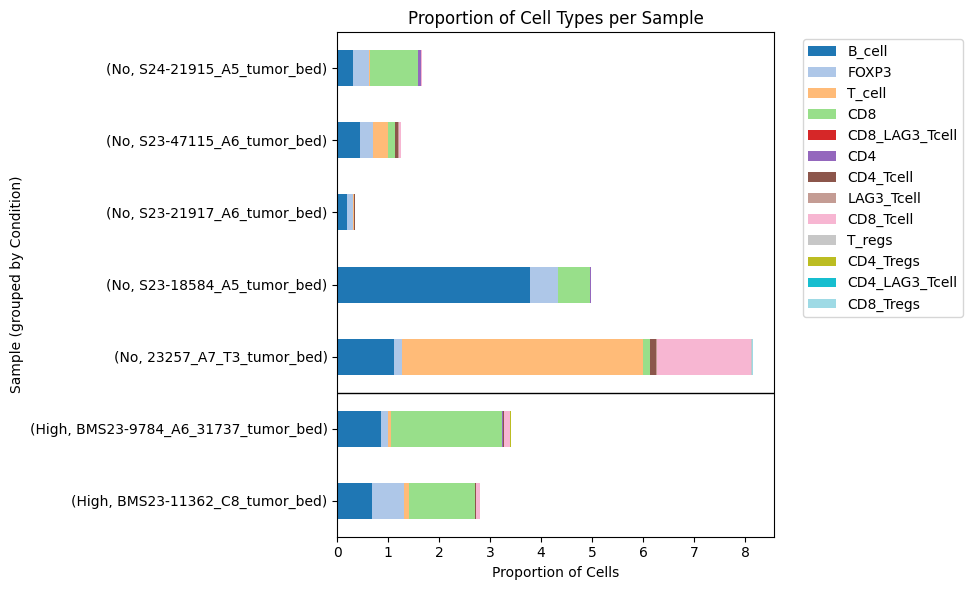

In [136]:
ax, results_df = t_test_plot(table_to_prov1, "MSI")

In [137]:
results_df[results_df['p_val']<0.05]


,cell_type,comparison,High_mean,No_mean,t_stat,p_val,direction,p_adj


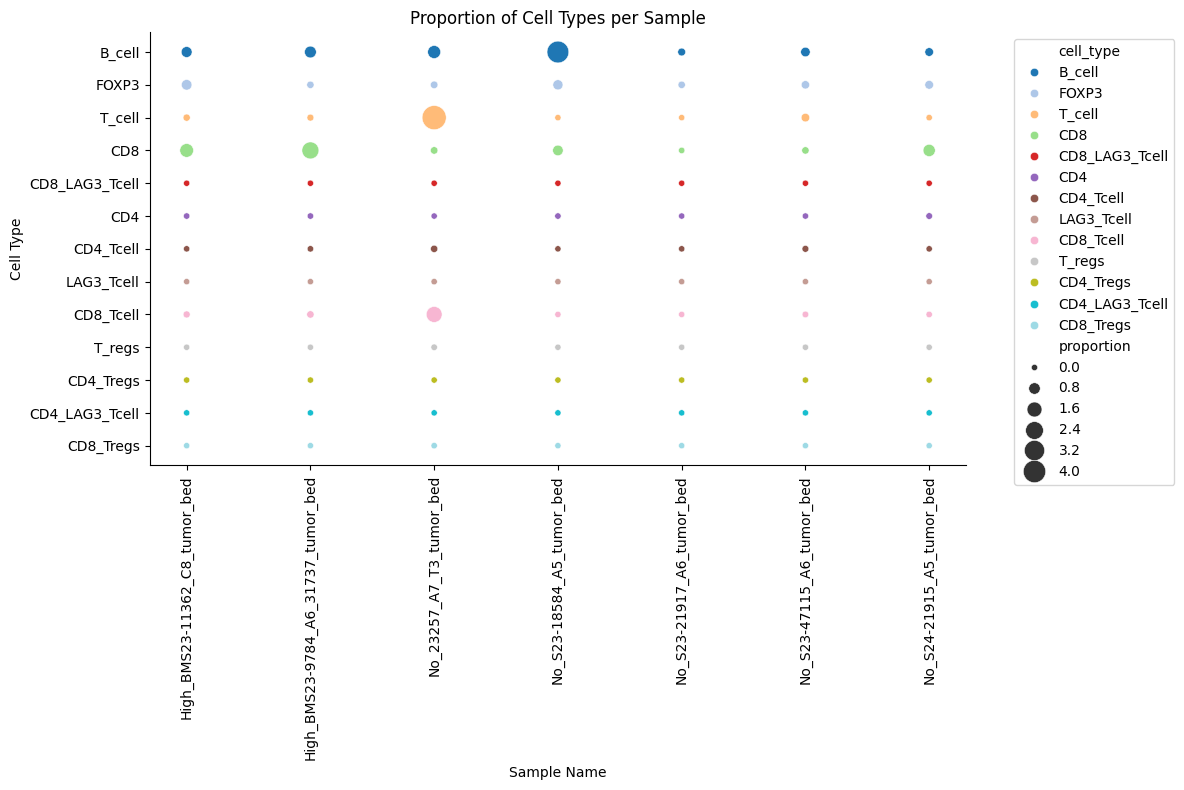

In [138]:
table_to_prov1.drop('MSI', axis=1, inplace=True)
dot_plot_for_doron(table_to_prov1, "MSI")

## Third comparison: Baseline vs Resections

In [139]:
sub_interest1 = sub_df[sub_df['Internal'].notna()]
subset_table = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sub_interest1['sample_region'].unique())]
table_to_prov1 = subset_table.set_index(["Internal", "sample_region"])
table_to_prov1 = table_to_prov1.sort_index(level=["Internal", "sample_region"])
table_to_prov1.drop(['Condition','MSI'], axis=1, inplace=True)

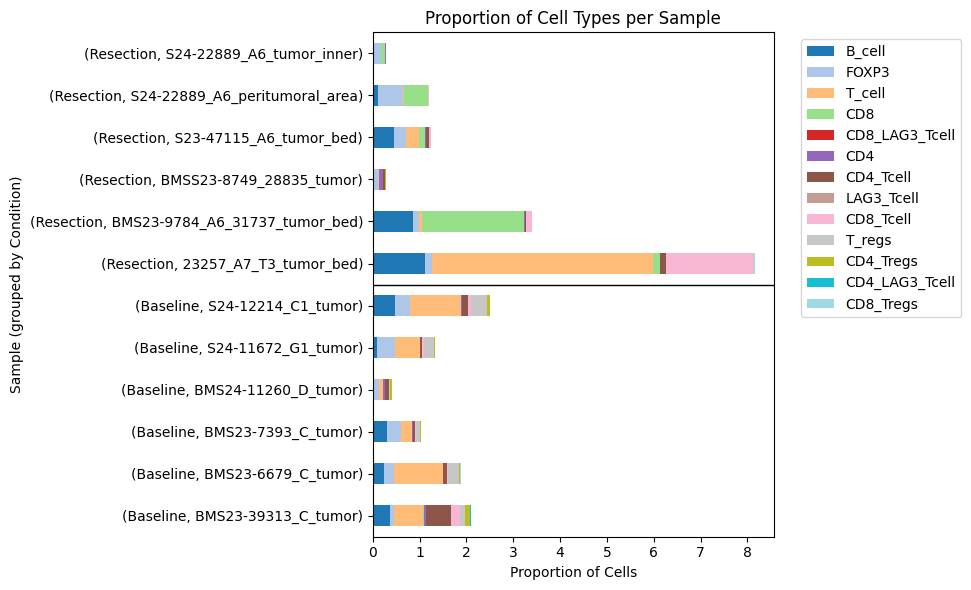

In [140]:
ax, results_df = t_test_plot(table_to_prov1, "Internal")

In [141]:
results_df[results_df['p_val']<0.05]


,cell_type,comparison,Baseline_mean,Resection_mean,t_stat,p_val,direction,p_adj
9,T_regs,Baseline_vs_Resection,0.162347,0.006547,3.301119,0.020846,up_in_Baseline,0.1355
10,CD4_Tregs,Baseline_vs_Resection,0.048630,0.002237,3.533800,0.016127,up_in_Baseline,0.1355


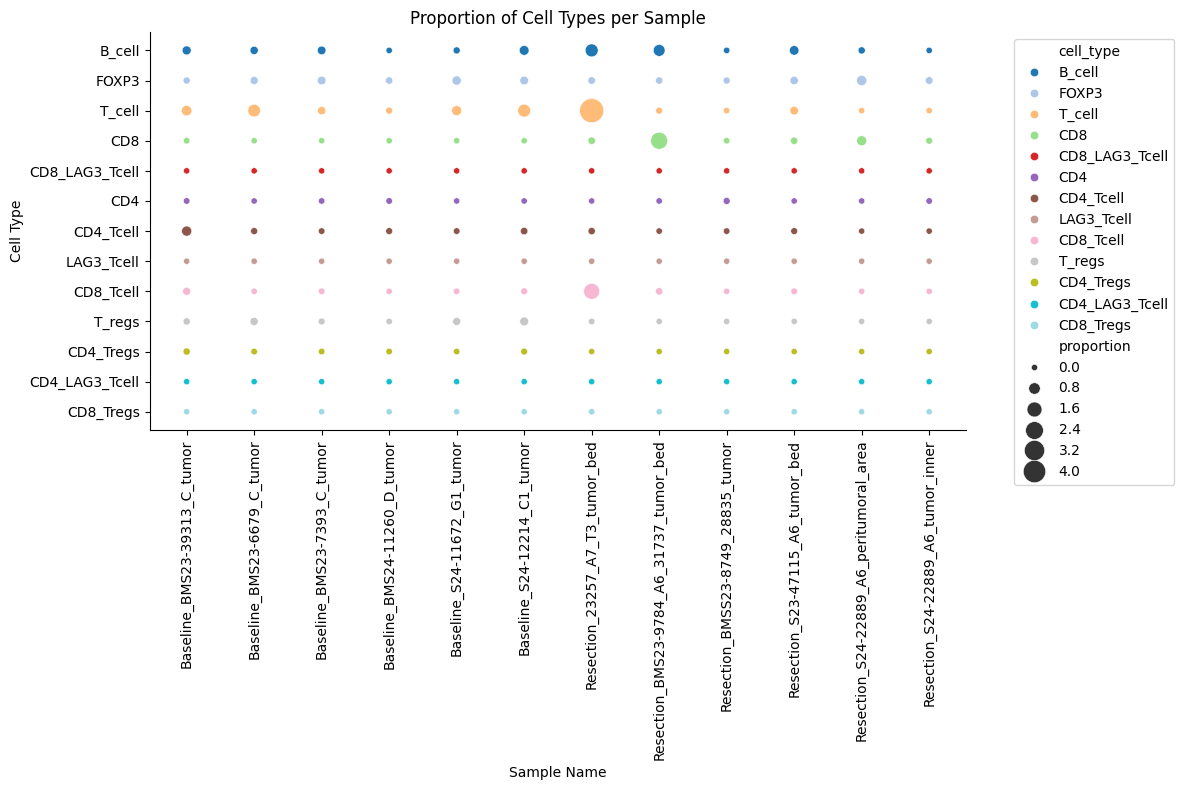

In [142]:
table_to_prov1.drop('Internal', axis=1, inplace=True)
dot_plot_for_doron(table_to_prov1, "Internal")

## Fourth comparison: within Baseline: Responders vs Non-responders

In [143]:
sub_interest1 = sub_df[sub_df['Internal']=="Baseline"]
sub_interest1['Baseline_comp']='Responder'
sub_interest1.loc[sub_interest1['sample_region'] == 'BMS24-11260_D_tumor', 'Baseline_comp'] = 'Non-responder'
sub_interest1.loc[sub_interest1['sample_region'] == 'BMS23-6679_C_tumor', 'Baseline_comp'] = 'Non-responder'

/tmp/ipykernel_4007144/709589333.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_interest1['Baseline_comp']='Responder'


In [144]:
to_merge = sub_interest1[['sample_region','Baseline_comp']].drop_duplicates()

In [145]:
subset_table = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sub_interest1['sample_region'].unique())]
subset_table = pd.merge(
    subset_table, to_merge,
    left_on=['sample_region'],
    right_on=['sample_region'],
    how="inner"
)

In [146]:
table_to_prov1 = subset_table.set_index(["Baseline_comp", "sample_region"])
table_to_prov1 = table_to_prov1.sort_index(level=["Baseline_comp", "sample_region"])
table_to_prov1.drop(['Condition','MSI','Internal'], axis=1, inplace=True)

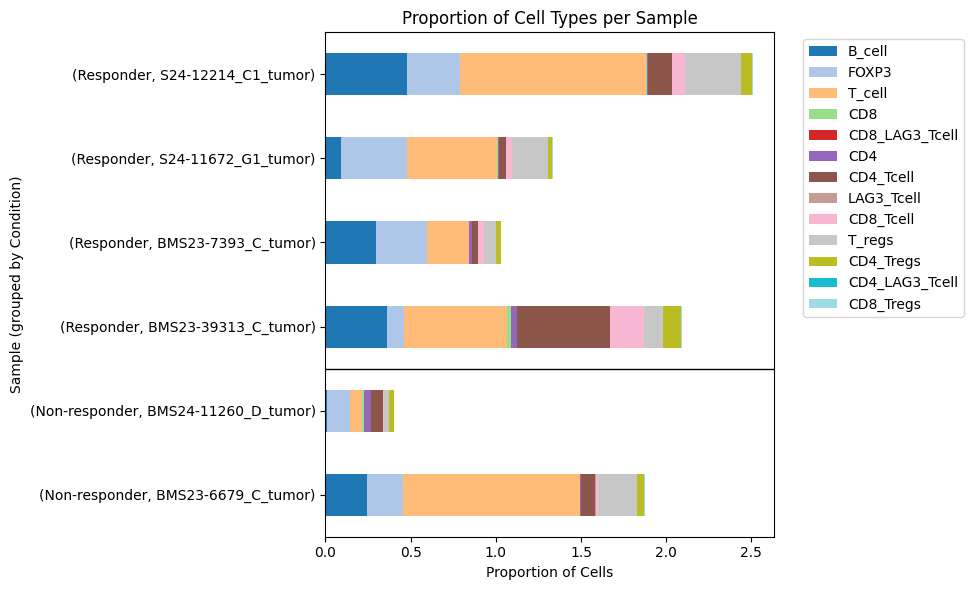

In [147]:
ax, results_df = t_test_plot(table_to_prov1, "Baseline_comp")

In [148]:
results_df[results_df['p_val']<0.05]


,cell_type,comparison,Non-responder_mean,Responder_mean,t_stat,p_val,direction,p_adj


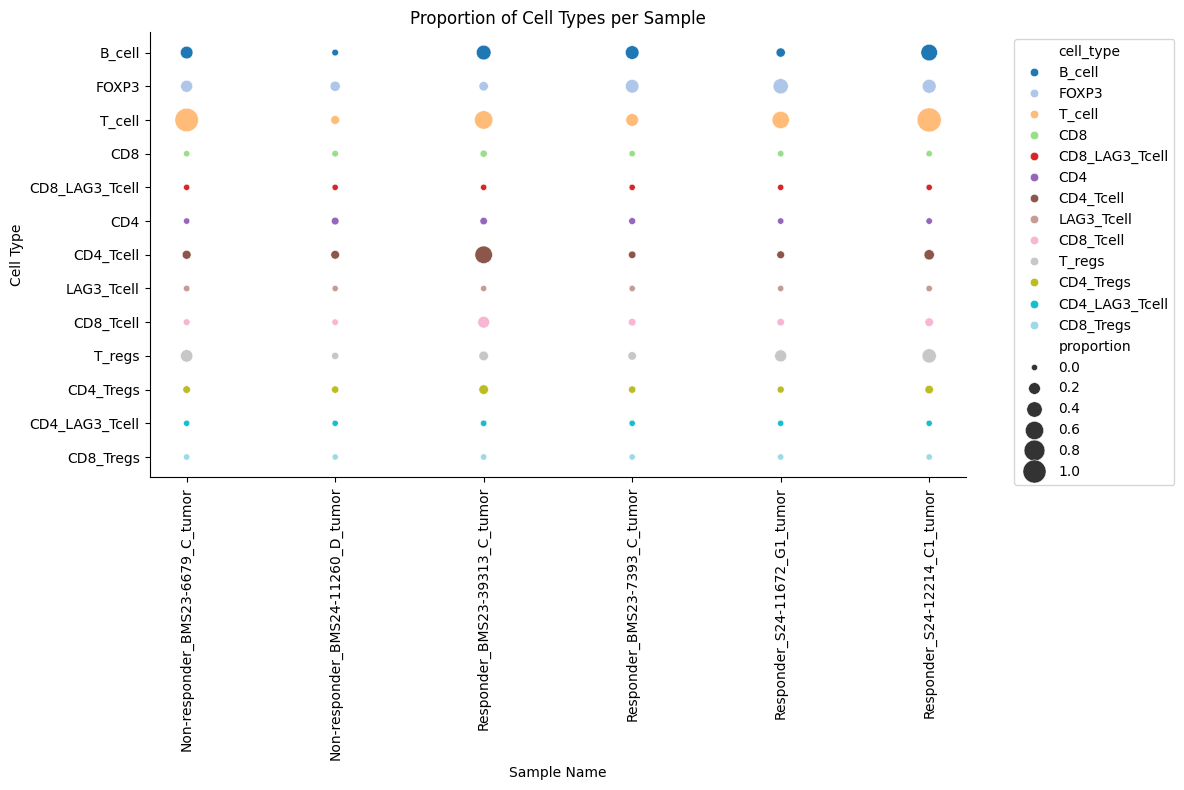

In [149]:
table_to_prov1.drop('Baseline_comp', axis=1, inplace=True)
dot_plot_for_doron(table_to_prov1, "Baseline_comp")

## Fifth comparison based on Non-reponders with WT and mutations of interest

In [169]:
sample_to_subset = ['S24-35674_A9_tumor_inner','S24-22889_A6_tumor_inner','S23-38315_A3_tumor_inner','BMSS23-8749_28835_tumor']
mutation_df = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sample_to_subset)]

In [170]:
#add mutation information to the samples
mutation_df['mutation_state']='WT'

/tmp/ipykernel_4007144/2604617412.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutation_df['mutation_state']='WT'


In [171]:
mutation_df.loc[mutation_df['sample_region'] == 'S24-22889_A6_tumor_inner', 'mutation_state'] = 'BRAF_V600R'
mutation_df.loc[mutation_df['sample_region'] == 'S24-35674_A9_tumor_inner', 'mutation_state'] = 'KRAS_G12D'


In [172]:
mutation_df = mutation_df.drop(columns=["Condition", "MSI", "Internal"])
mutation_df = mutation_df.set_index(["mutation_state", "sample_region"])


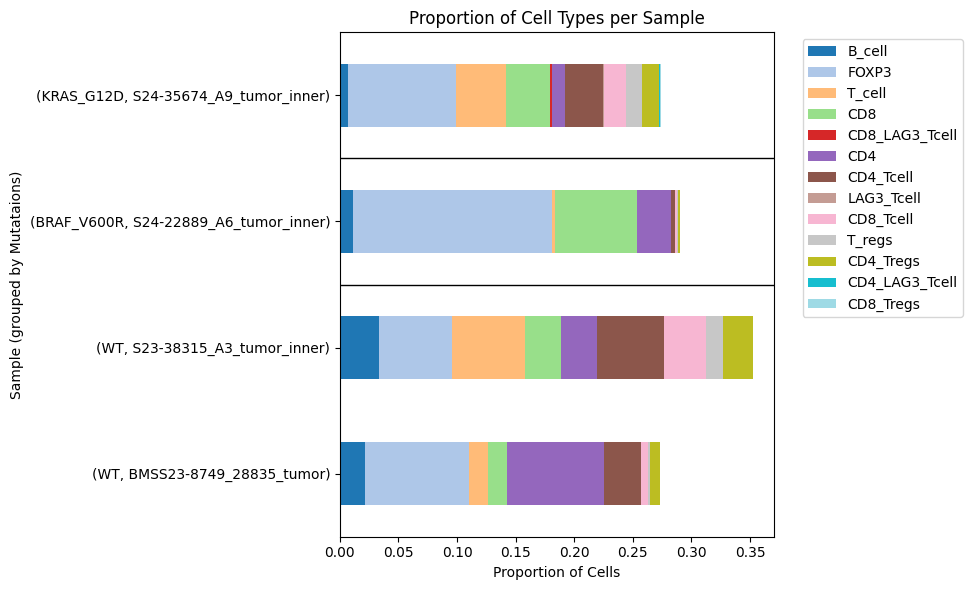

In [174]:
num_cell_types = mutation_df.shape[1]
cmap = cm.get_cmap('tab20', num_cell_types)
colors = [cmap(i) for i in range(num_cell_types)]

ax = mutation_df.plot(kind='barh', stacked=True, figsize=(10, 6), color=colors)

# add separator lines between conditions
# get index levels
conditions = mutation_df.index.get_level_values(0)
for i in range(1, len(conditions)):
    if conditions[i] != conditions[i-1]:
        ax.axhline(i-0.5, color="black", linewidth=1)  # separator

# legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(False)

plt.title('Proportion of Cell Types per Sample')
plt.xlabel('Proportion of Cells')
plt.ylabel('Sample (grouped by Mutataions)')
plt.tight_layout()
plt.show()


## Sixth comparison: baseline vs resection change in NEST2-04 (BRAF V600R) vs Nest1-04 (WT)

In [176]:
immune_normalized_area_table['sample_region'].unique()

array(['23257_A7_T3_tumor_bed', 'BMS23-11362_C8_tumor_bed',
       'BMS23-39313_C_tumor', 'BMS23-6679_C_tumor', 'BMS23-7393_C_tumor',
       'BMS23-9784_A6_31737_tumor_bed', 'BMS24-11260_D_tumor',
       'BMSS23-8749_28835_tumor', 'S23-18584_A5_tumor_bed',
       'S23-21917_A6_tumor_bed', 'S23-38315_A3_peritumoral_area',
       'S23-38315_A3_tumor_inner', 'S23-47115_A6_tumor_bed',
       'S24-11672_G1_tumor', 'S24-12214_C1_tumor',
       'S24-21915_A5_tumor_bed', 'S24-22889_A6_peritumoral_area',
       'S24-22889_A6_tumor_inner', 'S24-35674_A9_peritumoral_area',
       'S24-35674_A9_tumor_inner'], dtype=object)

In [181]:
sample_to_subset = ['S24-22889_A6_tumor_inner','BMS24-11260_D_tumor','BMSS23-8749_28835_tumor', 'BMS23-6679_C_tumor']
mutation_df = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sample_to_subset)]

In [182]:
#add mutation information to the samples
mutation_df['mutation_state']='Baseline'

/tmp/ipykernel_4007144/54563156.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutation_df['mutation_state']='Baseline'


In [183]:
mutation_df.loc[mutation_df['sample_region'] == 'S24-22889_A6_tumor_inner', 'mutation_state'] = 'Resection'
mutation_df.loc[mutation_df['sample_region'] == 'BMSS23-8749_28835_tumor', 'mutation_state'] = 'Resection'
mutation_df = mutation_df.drop(columns=["Condition", "MSI", "Internal"])
mutation_df = mutation_df.set_index(["mutation_state", "sample_region"])


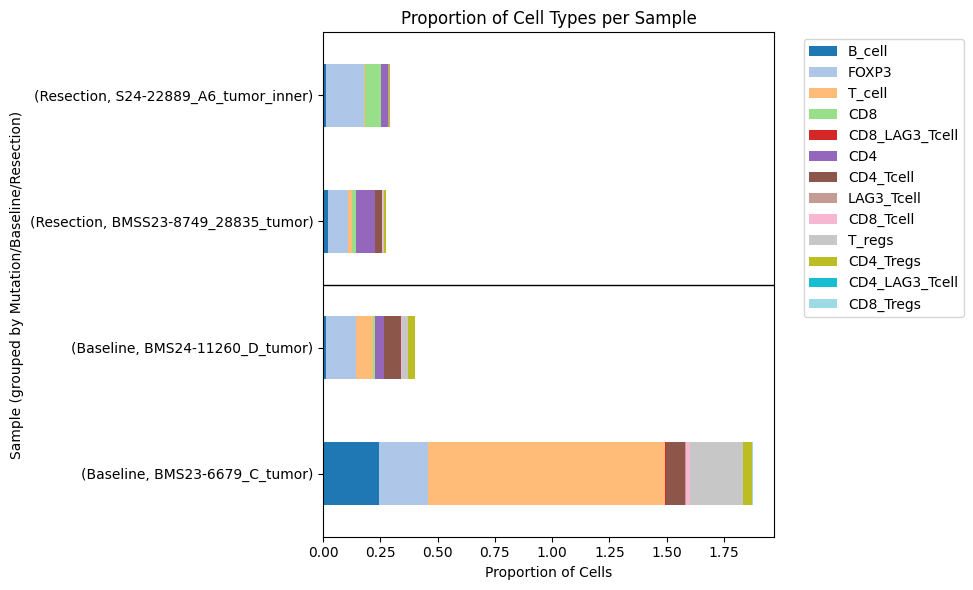

In [184]:
num_cell_types = mutation_df.shape[1]
cmap = cm.get_cmap('tab20', num_cell_types)
colors = [cmap(i) for i in range(num_cell_types)]

ax = mutation_df.plot(kind='barh', stacked=True, figsize=(10, 6), color=colors)

# add separator lines between conditions
# get index levels
conditions = mutation_df.index.get_level_values(0)
for i in range(1, len(conditions)):
    if conditions[i] != conditions[i-1]:
        ax.axhline(i-0.5, color="black", linewidth=1)  # separator

# legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(False)

plt.title('Proportion of Cell Types per Sample')
plt.xlabel('Proportion of Cells')
plt.ylabel('Sample (grouped by Mutation/Baseline/Resection)')
plt.tight_layout()
plt.show()